In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

Dataset escolhido:
E-Commerce Sales Dataset

Este conjunto de dados fornece uma visão abrangente dos dados de vendas de comércio eletrônico de diferentes canais, abrangendo uma variedade de produtos.

https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data

In [ ]:
file_path = '/content/drive/My Drive/Datasets_MBA/Amazon Sale Report.csv'

In [ ]:
df = pd.read_csv(file_path)
df.shape

<ipython-input-9-abb7c678210f>:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


(128975, 24)

In [ ]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
contagem_valores_em_branco = df.isna().sum()

print("Contagem de valores em branco em cada coluna:")
print(contagem_valores_em_branco)

Contagem de valores em branco em cada coluna:
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64


**Com o Head Foi possível identificar que existiam 22 colunas sem valor algum e com a contagem dos valores em branco tambem foi possível identificar que existem várias colunas com valores em branco**

In [ ]:
#Para corrigir as colunas em branco o primeiro passo foi identificar todos os nomes das colunas e após isso remover da lista o "Unamed"
nomes_colunas = df.columns.tolist()
print("Nomes das Colunas",nomes_colunas)

Nomes das Colunas ['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']


In [ ]:
nomes_colunas = ['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by']

In [ ]:
#Após a criação da lista final com todos os nomes corretos das colunas, substituir no DF.
df = df[nomes_colunas]
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN


In [ ]:
#Agora vamos para os valores em branco, e para isso temos 2 passos
# I - Como os valores em branco da coluna "Promotion - IDs" não necessariamente se referem a erros, mas sim a pedidos em que não houve aplicação de promoção, precisamos substituir os valores NaN por "Sem Promoção"
df['promotion-ids'].fillna("Sem promoção", inplace=True)

#Apos este passo, podemos aplicar o drop.na para remover todas as linhas sem valor aplicado

df = df.dropna()

#checagem após aplicação dos passos
contagem_valores_em_branco = df.isna().sum()

print("Contagem de valores em branco em cada coluna:")
print(contagem_valores_em_branco)


<ipython-input-15-c494d77bd912>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['promotion-ids'].fillna("Sem promoção", inplace=True)


Contagem de valores em branco em cada coluna:
index                 0
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
promotion-ids         0
B2B                   0
fulfilled-by          0
dtype: int64


In [ ]:
#Após o pre processamento dos dados, agora iremos para uma parte de entendimento preliminar, partindo pelos valores únicos para entender as caracteristicas de cada coluna

# Dicionário para armazenar os valores únicos de cada coluna
valores_unicos_por_coluna = {}

# Itera sobre cada coluna e obtém os valores únicos
for coluna in nomes_colunas:
    valores_unicos_por_coluna[coluna] = df[coluna].unique()
for coluna, valores_unicos in valores_unicos_por_coluna.items():
    print(f"Valores únicos da coluna '{coluna}':")
    print(valores_unicos)
    print()

Valores únicos da coluna 'index':
[     1      7     12 ... 128874 128887 128891]

Valores únicos da coluna 'Order ID':
['171-9198151-1101146' '406-7807733-3785945' '405-5513694-8146768' ...
 '405-4724097-1016369' '405-6493630-8542756' '403-0317423-9322704']

Valores únicos da coluna 'Date':
['04-30-22' '04-29-22' '04-28-22' '04-27-22' '04-26-22' '04-25-22'
 '04-24-22' '04-23-22' '04-22-22' '04-21-22' '04-20-22' '04-19-22'
 '04-18-22' '04-17-22' '04-16-22' '04-15-22' '04-14-22' '04-13-22'
 '04-12-22' '04-11-22' '04-10-22' '04-09-22' '04-08-22' '04-07-22'
 '04-06-22' '04-05-22' '04-04-22' '04-03-22' '04-02-22' '04-01-22'
 '03-31-22' '05-31-22' '05-30-22' '05-29-22' '05-28-22' '05-27-22'
 '05-26-22' '05-25-22' '05-24-22' '05-23-22' '05-22-22' '05-21-22'
 '05-20-22' '05-19-22' '05-18-22' '05-17-22' '05-16-22' '05-15-22'
 '05-14-22' '05-13-22' '05-12-22' '05-11-22' '05-10-22' '05-09-22'
 '05-08-22' '05-07-22' '05-06-22' '05-05-22' '05-04-22' '05-03-22'
 '05-02-22' '05-01-22' '06-29-22' '06

In [ ]:
for coluna in df.columns:
    # Calcular a contagem de valores únicos para cada coluna
    contagem_valores_unicos = df[coluna].nunique()
    # Mostrar a contagem de valores únicos para cada coluna
    print(f"Contagem de valores únicos para a coluna '{coluna}': {contagem_valores_unicos}")

Contagem de valores únicos para a coluna 'index': 32395
Contagem de valores únicos para a coluna 'Order ID': 29984
Contagem de valores únicos para a coluna 'Date': 91
Contagem de valores únicos para a coluna 'Status': 10
Contagem de valores únicos para a coluna 'Fulfilment': 1
Contagem de valores únicos para a coluna 'Sales Channel ': 1
Contagem de valores únicos para a coluna 'ship-service-level': 1
Contagem de valores únicos para a coluna 'Style': 1081
Contagem de valores únicos para a coluna 'SKU': 4601
Contagem de valores únicos para a coluna 'Category': 8
Contagem de valores únicos para a coluna 'Size': 11
Contagem de valores únicos para a coluna 'ASIN': 4599
Contagem de valores únicos para a coluna 'Courier Status': 2
Contagem de valores únicos para a coluna 'Qty': 5
Contagem de valores únicos para a coluna 'currency': 1
Contagem de valores únicos para a coluna 'Amount': 694
Contagem de valores únicos para a coluna 'ship-city': 4323
Contagem de valores únicos para a coluna 'ship-

In [ ]:
#Removendo do database as colunas com valores únicos para facilitar o trabalho
contagem_valores_unicos = df.nunique()
colunas_para_remover = contagem_valores_unicos[contagem_valores_unicos == 1].index

df = df.drop(columns=colunas_para_remover)

In [ ]:
#Aplicando o DTypes para verificar quais colunas são "Dimensões" e quais são "Medidas"
df.dtypes

index                 int64
Order ID             object
Date                 object
Status               object
Style                object
SKU                  object
Category             object
Size                 object
ASIN                 object
Courier Status       object
Qty                   int64
Amount              float64
ship-city            object
ship-state           object
ship-postal-code    float64
promotion-ids        object
B2B                    bool
dtype: object

<Figure size 2000x600 with 0 Axes>

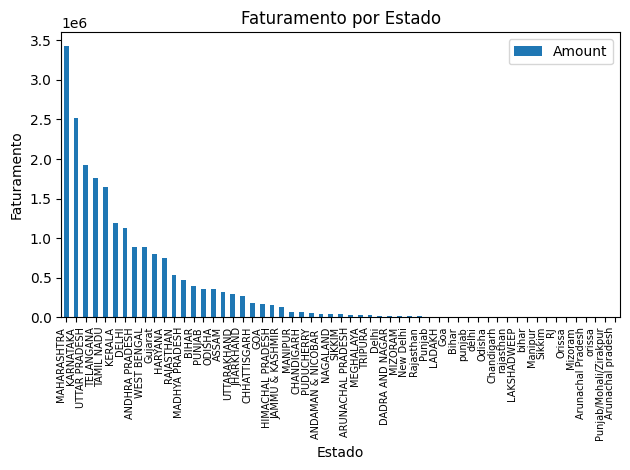

In [ ]:
# Passando pelo entendimento dos dados do faturamento de cada Estado
dados_agrupados_fatEstado = df.groupby('ship-state').aggregate({'Amount': 'sum'})

#ordenando do maior para o menor
dados_agrupados_fatEstado = dados_agrupados_fatEstado.sort_values(by='Amount', ascending=False)

# Gerar o gráfico de barras
plt.figure(figsize=(20, 6))
dados_agrupados_fatEstado.plot(kind='bar')
plt.title('Faturamento por Estado')
plt.xlabel('Estado')
plt.ylabel('Faturamento')
plt.xticks(rotation=90, ha='right')
plt.xticks(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
Lista_Estado = ['ANDHRA PRADESH' 'TAMIL NADU' 'KERALA' 'JAMMU & KASHMIR' 'MAHARASHTRA'
 'BIHAR' 'UTTAR PRADESH' 'KARNATAKA' 'RAJASTHAN' 'TELANGANA'
 'CHHATTISGARH' 'RJ' 'MADHYA PRADESH' 'ASSAM' 'JHARKHAND' 'HARYANA'
 'PUNJAB' 'WEST BENGAL' 'DELHI' 'UTTARAKHAND' 'GOA' 'HIMACHAL PRADESH'
 'ODISHA' 'Gujarat' 'Goa' 'TRIPURA' 'MANIPUR' 'CHANDIGARH' 'MIZORAM'
 'ANDAMAN & NICOBAR ' 'SIKKIM' 'NAGALAND' 'New Delhi' 'ARUNACHAL PRADESH'
 'Rajasthan' 'Delhi' 'delhi' 'PUDUCHERRY' 'MEGHALAYA' 'Punjab' 'Sikkim'
 'DADRA AND NAGAR' 'LAKSHADWEEP' 'Odisha' 'Bihar' 'punjab' 'bihar'
 'Arunachal pradesh' 'LADAKH' 'Mizoram' 'Chandigarh' 'Orissa']

## Solicitar entrada do usuário para o estado de envio desejado
estado_envio = input("\nDigite o estado de envio desejado (ou 'Todos' para considerar todos os estados): ")

# Criar filtro para as linhas da coluna 'ship-state'
if estado_envio.lower() == 'todos':
    filtro = ~df['ship-state'].isnull()  # Considerar todas as linhas
else:
    filtro = df['ship-state'] == estado_envio

# Aplicar o filtro ao DataFrame
df_filtrado = df.loc[filtro]

df_filtrado.head()


Digite o estado de envio desejado (ou 'Todos' para considerar todos os estados): KARNATAKA


,index,Order ID,Date,Status,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,promotion-ids,B2B
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.0,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,False
60,60,171-2592464-6846743,04-30-22,Shipped - Delivered to Buyer,NW005,NW005-ST-PJ-XL,Set,XL,B0922WJ27J,Shipped,1,599.0,BENGALURU,KARNATAKA,560023.0,Amazon PLCC Free-Financing Universal Merchant ...,False
72,72,407-2189901-7515567,04-30-22,Shipped - Delivered to Buyer,SET386,SET386-KR-NP-S,Set,S,B09K3YFPSS,Shipped,1,631.0,bangalore,KARNATAKA,560001.0,Amazon PLCC Free-Financing Universal Merchant ...,False
129,129,405-4908072-0260360,04-30-22,Shipped - Delivered to Buyer,MEN5032,MEN5032-KR-XXXL,kurta,3XL,B08YZ2ZXT7,Shipped,1,579.0,BENGALURU,KARNATAKA,560055.0,Amazon PLCC Free-Financing Universal Merchant ...,False
172,172,405-2660443-4165145,04-30-22,Shipped - Delivered to Buyer,JNE3405,JNE3405-KR-M,kurta,M,B081WVMMCY,Shipped,1,399.0,BENGALURU,KARNATAKA,560022.0,Amazon PLCC Free-Financing Universal Merchant ...,False


<Figure size 2000x600 with 0 Axes>

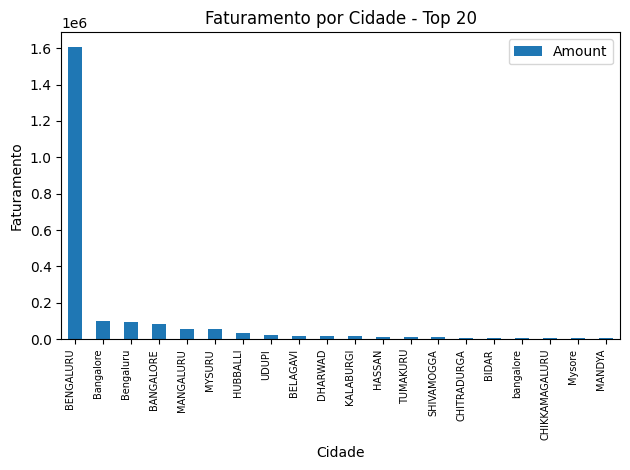

In [ ]:
# Passando pelo entendimento dos dados do faturamento de cada Estado
dados_agrupados_fatCidade = df_filtrado.groupby('ship-city').aggregate({'Amount': 'sum'})

#ordenando do maior para o menor
dados_agrupados_fatCidade = dados_agrupados_fatCidade.sort_values(by='Amount', ascending=False)

#filtrando para apenas as 20 maiores cidades
dados_agrupados_fatCidade = dados_agrupados_fatCidade.head(20)

# Gerar o gráfico de barras
plt.figure(figsize=(20, 6))
dados_agrupados_fatCidade.plot(kind='bar')
plt.title('Faturamento por Cidade - Top 20')
plt.xlabel('Cidade')
plt.ylabel('Faturamento')
plt.xticks(rotation=90, ha='right')
plt.xticks(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
## Solicitar entrada do usuário para o estado de envio desejado
cidade_envio = input("\nDigite a cidade de envio desejado (ou 'Todas' para considerar todas as cidades): ")

# Criar filtro para as linhas da coluna 'ship-state'
if cidade_envio.lower() == 'todas':
    filtro2 = ~df_filtrado['ship-city'].isnull()  # Considerar todas as linhas
else:
    filtro2 = df_filtrado['ship-city'] == cidade_envio

# Aplicar o filtro ao DataFrame
df_filtrado = df_filtrado.loc[filtro2]

df_filtrado.head()


Digite o estado de envio desejado (ou 'Todas' para considerar todas as cidades): Todas


,index,Order ID,Date,Status,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,promotion-ids,B2B
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.0,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,False
60,60,171-2592464-6846743,04-30-22,Shipped - Delivered to Buyer,NW005,NW005-ST-PJ-XL,Set,XL,B0922WJ27J,Shipped,1,599.0,BENGALURU,KARNATAKA,560023.0,Amazon PLCC Free-Financing Universal Merchant ...,False
72,72,407-2189901-7515567,04-30-22,Shipped - Delivered to Buyer,SET386,SET386-KR-NP-S,Set,S,B09K3YFPSS,Shipped,1,631.0,bangalore,KARNATAKA,560001.0,Amazon PLCC Free-Financing Universal Merchant ...,False
129,129,405-4908072-0260360,04-30-22,Shipped - Delivered to Buyer,MEN5032,MEN5032-KR-XXXL,kurta,3XL,B08YZ2ZXT7,Shipped,1,579.0,BENGALURU,KARNATAKA,560055.0,Amazon PLCC Free-Financing Universal Merchant ...,False
172,172,405-2660443-4165145,04-30-22,Shipped - Delivered to Buyer,JNE3405,JNE3405-KR-M,kurta,M,B081WVMMCY,Shipped,1,399.0,BENGALURU,KARNATAKA,560022.0,Amazon PLCC Free-Financing Universal Merchant ...,False


<Figure size 1000x600 with 0 Axes>

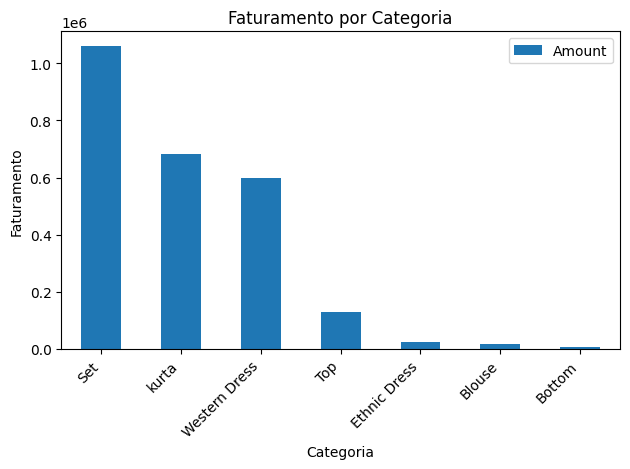

In [ ]:
# Passando pelo entendimento dos dados do faturamento de cada categoria
dados_agrupados_fatCategoria = df_filtrado.groupby('Category').aggregate({'Amount': 'sum'})

dados_agrupados_fatCategoria = dados_agrupados_fatCategoria.sort_values(by='Amount', ascending=False)

# Gerar o gráfico de barras
plt.figure(figsize=(10, 6))
dados_agrupados_fatCategoria.plot(kind='bar')
plt.title('Faturamento por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'kurta'),
  Text(1, 0, 'Set'),
  Text(2, 0, 'Western Dress'),
  Text(3, 0, 'Top'),
  Text(4, 0, 'Blouse'),
  Text(5, 0, 'Ethnic Dress'),
  Text(6, 0, 'Bottom')])

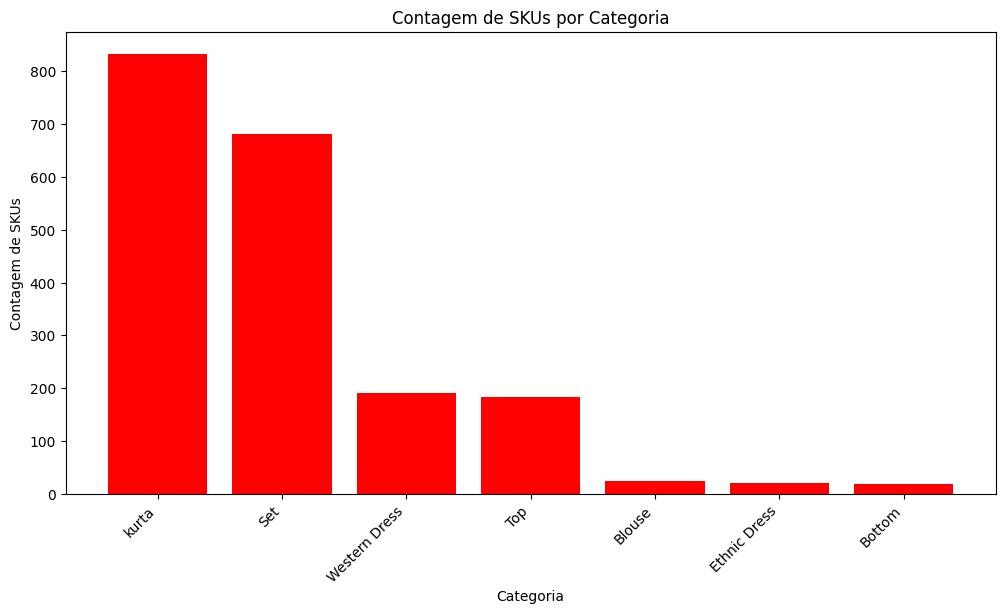

In [ ]:
# Passando pelo entendimento dos dados do faturamento de cada categoria
contagem_sku_por_categoria = df_filtrado.groupby('Category')['SKU'].nunique()

contagem_sku_por_categoria = contagem_sku_por_categoria.sort_values(ascending=False)

# Criar o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(contagem_sku_por_categoria.index, contagem_sku_por_categoria.values, color='red')

# Configurar o título e os rótulos dos eixos
plt.title('Contagem de SKUs por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Contagem de SKUs')
plt.xticks(rotation=45, ha='right')

In [ ]:
# Exibir os valores únicos da coluna 'Category'
valores_unicos_categoria = df_filtrado['Category'].unique()

# Exibir os valores únicos disponíveis para seleção
print("Valores únicos de categoria disponíveis para seleção:")
for categoria in valores_unicos_categoria:
    print(categoria)

# Solicitar entrada do usuário para a categoria desejada
while True:
    categoria_desejada = input("\nDigite a categoria desejada: ")

    # Verificar se a categoria desejada está na lista de valores únicos de categoria
    if categoria_desejada in valores_unicos_categoria:
        break
    else:
        print("Categoria inválida. Por favor, digite uma categoria válida.")

# Criar filtro para as linhas da coluna 'Category'
filtro_categoria = df_filtrado['Category'] == categoria_desejada

# Aplicar o filtro ao DataFrame
df_filtrado_por_categoria = df_filtrado.loc[filtro_categoria]

# Exibir os valores únicos da coluna 'Size' para a categoria selecionada
valores_unicos_tamanho = df_filtrado_por_categoria['Size'].unique()

# Solicitar entrada do usuário para o tamanho desejado
while True:
    print("\nValores únicos de tamanho disponíveis para seleção:")
    for tamanho in valores_unicos_tamanho:
        print(tamanho)
    tamanho_desejado = input("\nDigite o tamanho desejado (ou 'Todos' para considerar todos os tamanhos): ")

    # Verificar se o tamanho desejado está na lista de valores únicos de tamanho
    if tamanho_desejado == 'Todos' or tamanho_desejado in valores_unicos_tamanho:
        break
    else:
        print("Tamanho inválido. Por favor, digite um tamanho válido.")

# Se o tamanho for diferente de 'Todos', aplicar filtro ao DataFrame
if tamanho_desejado != 'Todos':
    filtro_tamanho = df_filtrado_por_categoria['Size'] == tamanho_desejado
    df_filtrado = df_filtrado_por_categoria.loc[filtro_tamanho]

Valores únicos de categoria disponíveis para seleção:
kurta
Set
Western Dress
Top
Blouse
Ethnic Dress
Bottom

Digite a categoria desejada: Set

Valores únicos de tamanho disponíveis para seleção:
XL
S
L
XXL
3XL
XS
M
4XL
6XL

Digite o tamanho desejado (ou 'Todos' para considerar todos os tamanhos): Todos


In [ ]:
# Exibir os valores únicos da coluna 'Status'
valores_unicos_status = df_filtrado['Status'].unique()

# Exibir os valores únicos disponíveis para seleção
print("\nValores únicos de Status disponíveis para seleção:")
for status in valores_unicos_status:
    print(status)

# Solicitar entrada do usuário para o Status do Pedido desejado
while True:
    status_desejado = input("\nDigite o Status do Pedido desejado: ")

    # Verificar se o Status do Pedido desejado está na lista de valores únicos de Status
    if status_desejado in valores_unicos_status:
        break
    else:
        print("Status inválido. Por favor, digite um Status válido.")

# Criar filtro para as linhas da coluna 'Status'
filtro_status = df_filtrado['Status'] == status_desejado

# Aplicar o filtro ao DataFrame
df_filtrado_por_status = df_filtrado[filtro_status]


Valores únicos de Status disponíveis para seleção:
Shipped - Delivered to Buyer
Shipped - Rejected by Buyer
Shipped - Returned to Seller
Shipped - Lost in Transit
Pending
Pending - Waiting for Pick Up
Shipped - Picked Up
Shipped - Returning to Seller
Shipped - Out for Delivery

Digite o Status do Pedido desejado: Shipped - Delivered to Buyer


In [ ]:
#contagem_valores_unicos2 = df_filtrado.nunique()

# Identificar as colunas que possuem apenas um valor único
#colunas_para_remover2 = contagem_valores_unicos2[contagem_valores_unicos2 == 1].index

# Remover as colunas que possuem apenas um valor único
#df_filtrado = df_filtrado.drop(columns=colunas_para_remover2)

df_filtrado.head()

,index,Order ID,Date,Status,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,promotion-ids,B2B
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.0,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,False
60,60,171-2592464-6846743,04-30-22,Shipped - Delivered to Buyer,NW005,NW005-ST-PJ-XL,Set,XL,B0922WJ27J,Shipped,1,599.0,BENGALURU,KARNATAKA,560023.0,Amazon PLCC Free-Financing Universal Merchant ...,False
72,72,407-2189901-7515567,04-30-22,Shipped - Delivered to Buyer,SET386,SET386-KR-NP-S,Set,S,B09K3YFPSS,Shipped,1,631.0,bangalore,KARNATAKA,560001.0,Amazon PLCC Free-Financing Universal Merchant ...,False
129,129,405-4908072-0260360,04-30-22,Shipped - Delivered to Buyer,MEN5032,MEN5032-KR-XXXL,kurta,3XL,B08YZ2ZXT7,Shipped,1,579.0,BENGALURU,KARNATAKA,560055.0,Amazon PLCC Free-Financing Universal Merchant ...,False
172,172,405-2660443-4165145,04-30-22,Shipped - Delivered to Buyer,JNE3405,JNE3405-KR-M,kurta,M,B081WVMMCY,Shipped,1,399.0,BENGALURU,KARNATAKA,560022.0,Amazon PLCC Free-Financing Universal Merchant ...,False


In [ ]:
# Agrupar o DataFrame por 'Style' e encontrar os valores únicos de 'Sku' para cada grupo
#valores_unicos_sku_por_style = df_filtrado.groupby('Style')['SKU'].apply(lambda x: x.nunique())

# Exibir os valores únicos de 'Sku' para cada 'Style'
#print(valores_unicos_sku_por_style)

In [ ]:
# Somar as colunas 'Qty' e 'Amount' agrupadas pela coluna 'Style'
df_sku = df_filtrado.groupby('Style')[['Qty', 'Amount']].sum()

# Resetar o índice para que 'Style' volte a ser uma coluna
df_sku = df_sku.reset_index()

# Criar a nova coluna 'Price' que é a divisão de 'Amount' por 'Qty'
df_sku['Price'] = df_sku['Amount'] / df_sku['Qty']

# Ordenar o DataFrame pela coluna 'Amount' em ordem decrescente
df_sku = df_sku.sort_values(by='Amount', ascending=False)

# Exibir o DataFrame resultante
print(df_sku.head())

       Style  Qty    Amount       Price
457  JNE3797  333  244565.0  734.429429
155    J0341   64   51571.0  805.796875
460  JNE3800   65   46504.0  715.446154
24     J0003   64   41002.0  640.656250
458  JNE3798   54   39516.0  731.777778


In [ ]:
from sklearn.preprocessing import StandardScaler
cols_to_normalize = ['Price', 'Qty', 'Amount']

# Inicializar o StandardScaler
scaler = StandardScaler()

# Normalizar as colunas selecionadas
df_sku[cols_to_normalize] = scaler.fit_transform(df_sku[cols_to_normalize])

# Exibir as primeiras linhas do DataFrame normalizado
print(df_sku.head())

       Style        Qty     Amount     Price
457  JNE3797  23.358013  23.610900  0.505607
155    J0341   4.173027   4.713158  0.769767
460  JNE3800   4.244346   4.217004  0.435343
24     J0003   4.173027   3.678254  0.158515
458  JNE3798   3.459830   3.532747  0.495793


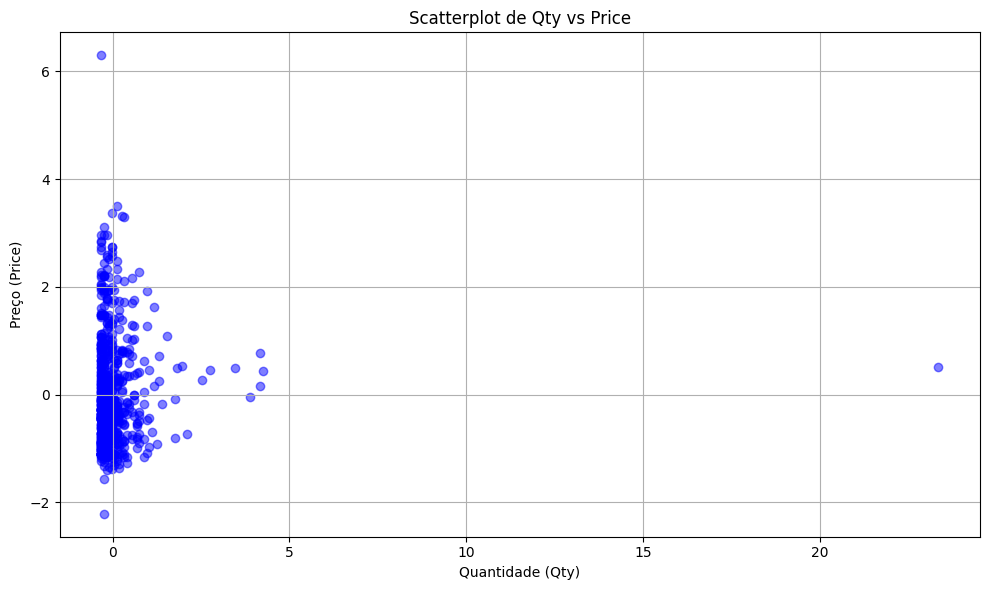

In [ ]:
# Extrair as colunas 'Qty' e 'Price'
quantidade = df_sku['Qty']
preco = df_sku['Price']

# Criar o scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(quantidade, preco, color='blue', alpha=0.5)

# Adicionar rótulos e título
plt.xlabel('Quantidade (Qty)')
plt.ylabel('Preço (Price)')
plt.title('Scatterplot de Qty vs Price')

# Exibir o gráfico
plt.grid(True)
plt.tight_layout()
plt.show()

Digite o valor máximo para quantidade (Qty): 5
Digite o valor mínimo para quantidade (Qty): -10
Digite o valor máximo para preço (Price): 4
Digite o valor mínimo para preço (Price): -2


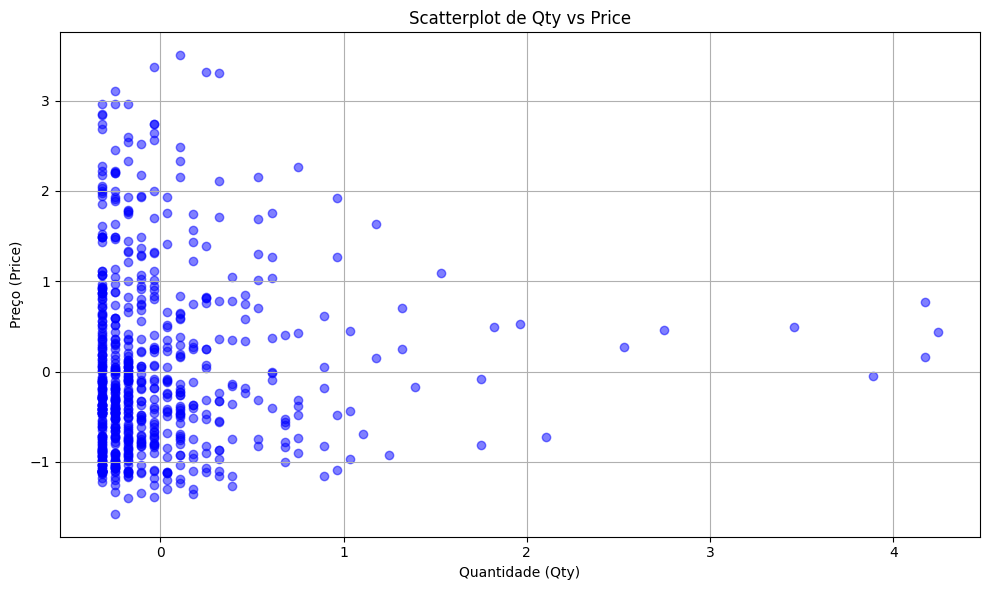

In [ ]:
# Removendo Outliers
Outlier_Quantidade_Max = float(input("Digite o valor máximo para quantidade (Qty): "))
Outlier_Quantidade_Min = float(input("Digite o valor mínimo para quantidade (Qty): "))
Outlier_Preço_Max = float(input("Digite o valor máximo para preço (Price): "))
Outlier_Preço_Min = float(input("Digite o valor mínimo para preço (Price): "))

df_sku = df_sku[df_sku['Qty'] < Outlier_Quantidade_Max]
df_sku = df_sku[df_sku['Qty'] > Outlier_Quantidade_Min]
df_sku = df_sku[df_sku['Price'] < Outlier_Preço_Max]
df_sku = df_sku[df_sku['Price'] > Outlier_Preço_Min]
# Extrair as colunas 'Qty' e 'Price'
quantidade = df_sku['Qty']
preco = df_sku['Price']

# Criar o scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(quantidade, preco, color='blue', alpha=0.5)

# Adicionar rótulos e título
plt.xlabel('Quantidade (Qty)')
plt.ylabel('Preço (Price)')
plt.title('Scatterplot de Qty vs Price')

# Exibir o gráfico
plt.grid(True)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

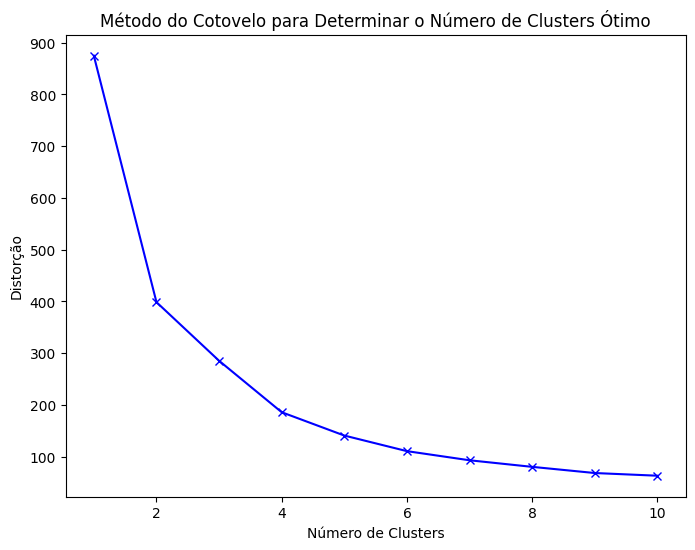

In [ ]:
# Selecionar as colunas 'Qty' e 'Price' do DataFrame
X = df_sku[['Qty', 'Price']]

distortions = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

# Plotar o gráfico de cotovelo (Elbow Method)
plt.figure(figsize=(8, 6))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de Clusters')
plt.ylabel('Distorção')
plt.title('Método do Cotovelo para Determinar o Número de Clusters Ótimo')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


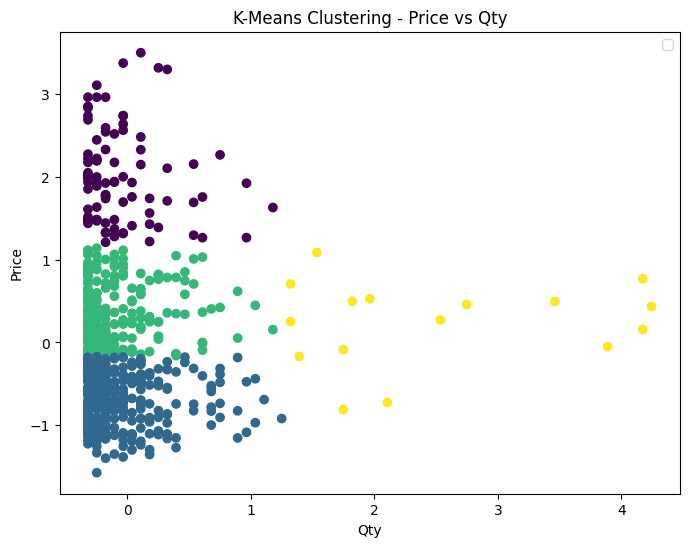

In [ ]:
X = df_sku[['Price', 'Qty']]

# Inicializar e ajustar o modelo KMeans com o número desejado de clusters
kmeans = KMeans(n_clusters=4, random_state = 42)  # Você pode ajustar o número de clusters conforme necessário
kmeans.fit(X)

# Adicionar as labels dos clusters ao DataFrame df_sku
df_sku['Cluster'] = kmeans.labels_

# Plotar os clusters
plt.figure(figsize=(8, 6))
plt.scatter(df_sku['Qty'], df_sku['Price'], c=df_sku['Cluster'], cmap='viridis', alpha=1)
plt.xlabel('Qty')
plt.ylabel('Price')
plt.title('K-Means Clustering - Price vs Qty')


plt.legend()
plt.show()

In [ ]:
# Silhouette Score
silhouette_avg = silhouette_score(X, kmeans.labels_)

# Davies-Bouldin Index
db_index = davies_bouldin_score(X, kmeans.labels_)

print("Silhouette Score = ",silhouette_avg,"; ","Davies-Bouldin Index Score = ",db_index,)

Silhouette Score =  0.4708289849095914 ;  Davies-Bouldin Index Score =  0.6812066417470551


In [ ]:
# Selecionar as colunas 'Price' e 'Qty' do DataFrame df_sku
X = df_sku[['Qty', 'Price']]

# Inicializar e ajustar o modelo KMeans com o número desejado de clusters
kmeans = KMeans(n_clusters=4, random_state = 42)
kmeans.fit(X)


# Exibir o DataFrame com a nova coluna
df_sku.head()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,Style,Qty,Amount,Price,Cluster
155,J0341,4.173027,4.713158,0.769767,3
460,JNE3800,4.244346,4.217004,0.435343,3
24,J0003,4.173027,3.678254,0.158515,3
458,JNE3798,3.459830,3.532747,0.495793,3
670,SET324,3.887748,3.094560,-0.051131,3


In [ ]:
df_sku.reset_index(drop=True, inplace=True)

df_sku.head()

,Style,Qty,Amount,Price,Cluster
0,J0341,4.173027,4.713158,0.769767,3
1,JNE3800,4.244346,4.217004,0.435343,3
2,J0003,4.173027,3.678254,0.158515,3
3,JNE3798,3.459830,3.532747,0.495793,3
4,SET324,3.887748,3.094560,-0.051131,3


In [ ]:
df_sku.to_excel('Output_Kmean.xlsx', index=False)